## Module 1 — Foundations and Mental Model

This module is mostly conceptual. The goal is to make `fig, ax = plt.subplots()` feel concrete: what objects are created, how they relate to each other, and why the object-oriented API is the default habit to build.

## 1. The Figure → Axes → Artist hierarchy

Every matplotlib plot is built from three nested concepts. Internalizing this hierarchy explains much of how matplotlib works.

```text
┌─────────────────────────────────────────────────────┐
│ FIGURE: the window / page / canvas                  │
│                                                     │
│   ┌──────────────────┐     ┌──────────────────┐     │
│   │ AXES             │     │ AXES             │     │
│   │ one plot panel   │     │ one plot panel   │     │
│   │                  │     │                  │     │
│   │   ┌─ title ─┐    │     │   ┌─ title ─┐    │     │
│   │   │ • •     │    │     │   │ • •     │    │     │
│   │   │ • • •   │    │     │   │ • • •   │    │     │
│   │   └─x-axis──┘    │     │   └─x-axis──┘    │     │
│   │      y-axis      │     │      y-axis      │     │
│   └──────────────────┘     └──────────────────┘     │
│                                                     │
│ ARTISTS: lines, dots, text, legends, ticks, patches │
└─────────────────────────────────────────────────────┘
```

There are three terms to keep straight:

- **Figure** — the entire canvas. There is one `Figure` per image saved or displayed. Think of it as the sheet of paper.
- **Axes** — a single plot panel, including its title, axis labels, tick marks, and the data drawn inside. Important gotcha: **Axes** is singular in matplotlib's object model, even though the word looks plural.
- **Artist** — everything visible on the figure: lines, scatter dots, text, legends, ticks, patches, and even backgrounds. Most visible elements are `Artist` objects.

A `Figure` can contain many `Axes` objects. Each `Axes` usually contains two `Axis` objects: the x-axis and y-axis rulers.

### Mapping to ggplot2

| ggplot2 concept | matplotlib concept |
|---|---|
| the whole rendered plot | `Figure` |
| one facet panel | `Axes` |
| `geom_point()` output | an `Artist`, often a `PathCollection` |
| `geom_line()` output | an `Artist`, usually a `Line2D` |
| theme text element | an `Artist`, usually a `Text` object |

In ggplot2, these objects are mostly hidden behind the grammar of graphics. In matplotlib, the objects are explicit and are modified through method calls. That is the main imperative shift.

## 2. The two APIs: pyplot and object-oriented

Matplotlib has two common ways to draw the same plot. Many tutorials mix them freely, which is one reason matplotlib can feel confusing at first.

### The pyplot state-machine API

The `pyplot` API is MATLAB-style. It keeps a hidden global idea of the current figure and current axes. Each `plt.*` call modifies whichever object is currently active.

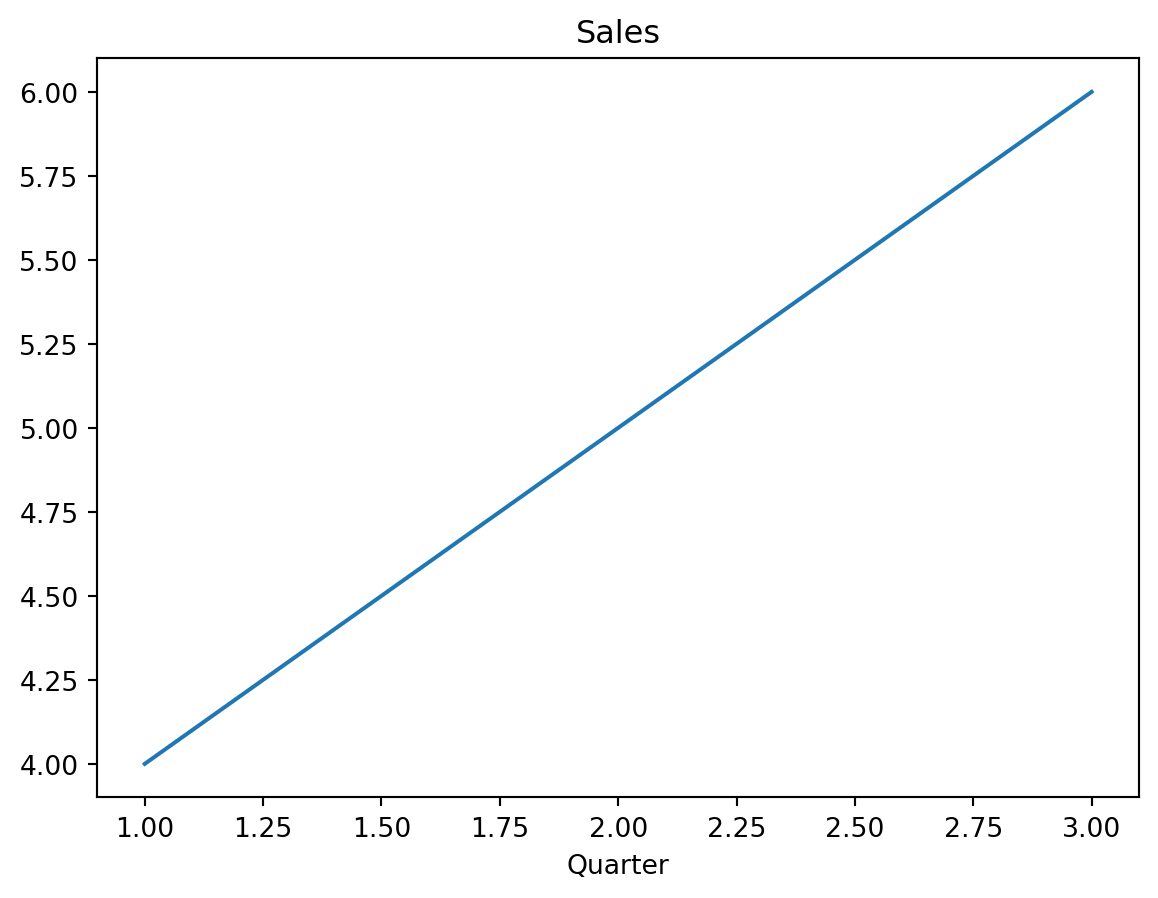

In [1]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Sales")
plt.xlabel("Quarter")
plt.show()

This is convenient for quick one-off plots, but it becomes ambiguous when there are multiple panels. If there are several axes, `plt.title()` titles whichever axes matplotlib considers current.

### The object-oriented API

The object-oriented API creates explicit `Figure` and `Axes` objects, then calls methods on those objects.

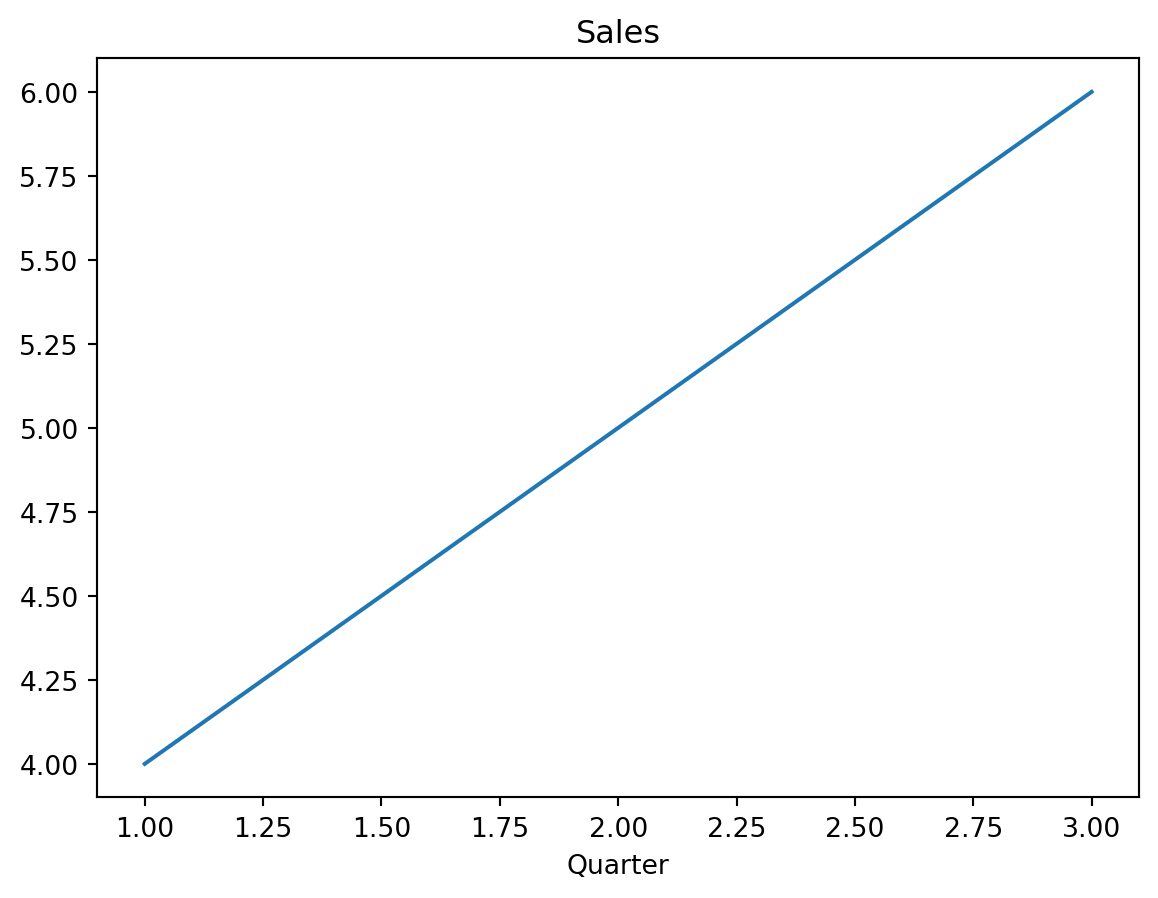

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()  # explicitly create Figure and Axes
ax.plot([1, 2, 3], [4, 5, 6])  # draw on this Axes object
ax.set_title("Sales")
ax.set_xlabel("Quarter")
plt.show()

With the object-oriented API, every modification targets a specific object. There is no need to depend on hidden global state.

```text
pyplot style                         OO style
──────────────────────               ───────────────────────
plt → hidden state → drawing          you → fig, ax → drawing
```

The standard idiom is a small hybrid: `plt.subplots()` is a `pyplot` function, but it returns explicit `Figure` and `Axes` objects so the rest of the code can use the OO API.

## 3. Why the OO API wins

Use the object-oriented API for anything beyond a throwaway exploratory plot.

The advantages become obvious as soon as a figure has more than one subplot. With pyplot, `plt.title()` depends on which panel is current. With the OO API, `ax1.set_title(...)` and `ax2.set_title(...)` are explicit.

The OO style is also easier to:

- wrap in functions by passing `ax` as an argument
- debug because the target object is visible
- combine with seaborn and pandas plotting functions
- extend into multi-panel publication figures

Pyplot is still fine for a quick `plt.hist(data)` in an exploratory notebook cell. For reusable notes, teaching material, and publication figures, the OO API should be the default.

## 4. Setup in this book project

This book uses a local `uv` environment. The project dependencies include matplotlib, NumPy, pandas, seaborn, SciPy, Jupyter Notebook, and IPython kernel support.

From the project root:

```bash
uv sync
uv run jupyter notebook
```

The first code cell of most plotting notebooks usually starts with:

In [3]:
import matplotlib.pyplot as plt
import numpy as np

No backend configuration is required for normal notebook use. VS Code's Jupyter integration and Jupyter Notebook render plots inline by default.

## 5. Backends

A backend is the rendering engine that turns matplotlib instructions into pixels or vector graphics. It is rarely necessary to set the backend manually, but the categories are useful when debugging.

```text
┌──────────────────────────────────────────────────────┐
│ Interactive backends: open a window                  │
│ • MacOSX — common on macOS for plain Python          │
│ • QtAgg / Qt5Agg — cross-platform GUI                │
│ • TkAgg — Tk-based GUI fallback                      │
├──────────────────────────────────────────────────────┤
│ Inline backends: embed in notebooks                  │
│ • inline — static PNG in the notebook                │
│ • widget — interactive zoom/pan in the notebook      │
├──────────────────────────────────────────────────────┤
│ Non-interactive / file-only backends                 │
│ • Agg — PNG output, no display, useful in scripts    │
│ • PDF, SVG, PS — vector formats for publication      │
└──────────────────────────────────────────────────────┘
```

In a notebook, the inline backend is usually enough. For interactive zoom and pan inside notebooks, `%matplotlib widget` can be used after installing `ipympl`. For now, the default inline behavior is the cleanest baseline.

## 6. Hello world: the object-oriented API

This is the minimal plot that demonstrates the standard matplotlib workflow.

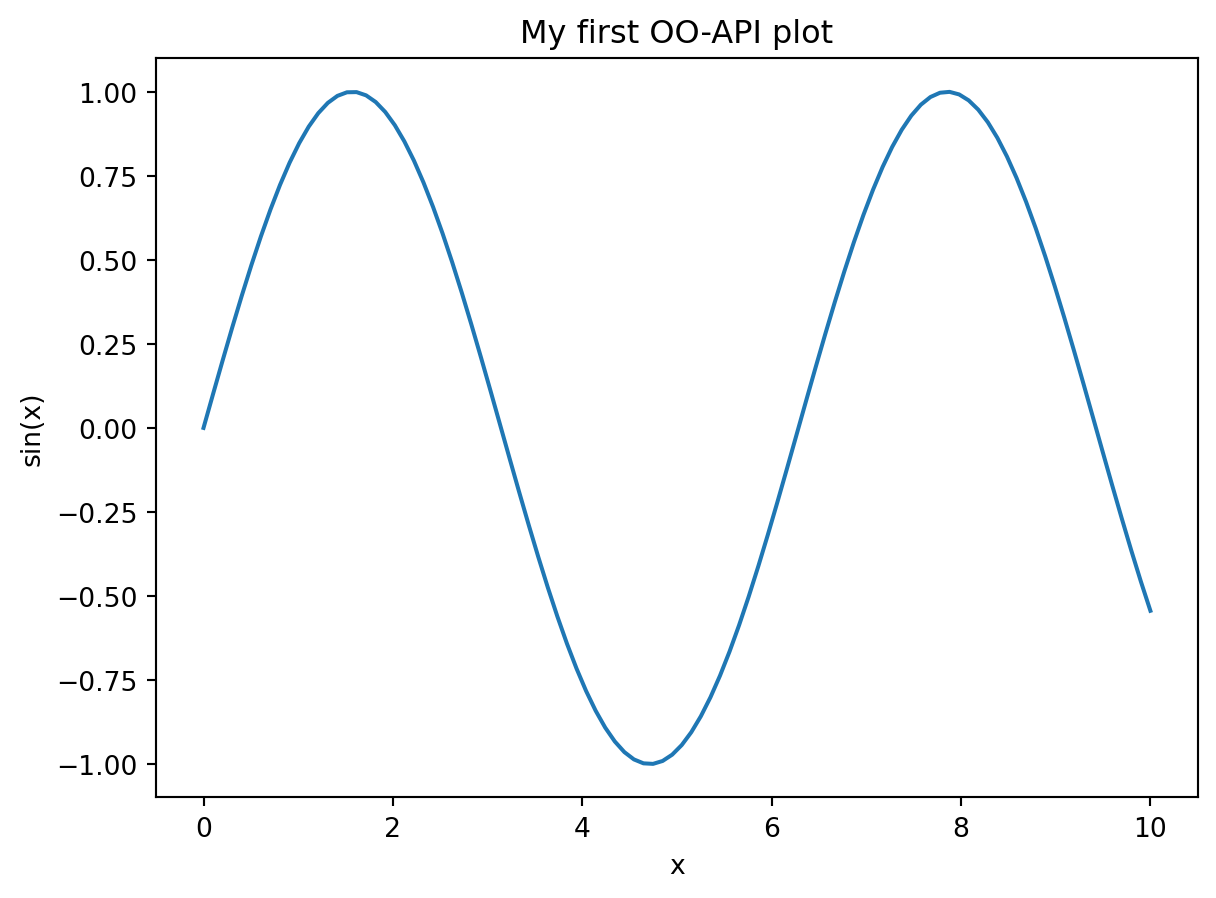

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title("My first OO-API plot")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
plt.show()

print(type(fig))
print(type(ax))

## Key takeaways

- A `Figure` is the full canvas.
- An `Axes` is one plot panel inside a figure.
- An `Axis` is a ruler-like component of an axes, such as the x-axis or y-axis.
- An `Artist` is any visible object drawn on the figure.
- `plt.subplots()` is the standard entry point because it creates explicit `Figure` and `Axes` objects.
- The OO API is the right default for multi-panel, reusable, and publication-quality figures.